In [1]:
from DirectoryReader import DirectoryReader

d = DirectoryReader('files/swansea')
df = d.generate_dataframe()

In [9]:
# Let's add a column Expired which is true if deadline > 
import pandas as pd

# Convert to datetime
df["date_obtained"] = pd.to_datetime(
    df["date_obtained"],
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

df["deadline"] = pd.to_datetime(
    df["deadline"],
    format="%d/%m/%Y",
    errors="coerce"
)

# True if date_obtained is after deadline
df["expired"] = (
    df["deadline"].notna()
    & (df["date_obtained"] > df["deadline"])
)

In [5]:
ocids = df['ocid'].dropna().unique().tolist()
print(len(ocids))

from Searcher import Searcher

Searcher.save_ocid_latest_contract_dict(ocids, 'files/swansea/ocids.json')

289
Done 1 / 289
Done 2 / 289
Done 3 / 289
Done 4 / 289
Rate limited. Waiting 120s for ocds-kuma6s-158380
Done 7 / 289
Done 8 / 289
Done 9 / 289
Done 10 / 289
Done 11 / 289
Done 12 / 289
Done 17 / 289
Done 21 / 289
Done 22 / 289
Done 23 / 289
Done 24 / 289
Done 25 / 289
Done 26 / 289
Done 27 / 289
Done 28 / 289
Done 29 / 289
Done 30 / 289
Done 31 / 289
Done 34 / 289
Done 38 / 289
Done 42 / 289
Done 43 / 289
Done 44 / 289
Done 45 / 289
Done 46 / 289
Done 47 / 289
Done 49 / 289
Done 51 / 289
Done 52 / 289
Done 53 / 289
Done 54 / 289
Done 62 / 289
Done 67 / 289
Done 71 / 289
Done 72 / 289
Done 73 / 289
Done 74 / 289
Done 75 / 289
Done 76 / 289
Done 77 / 289
Done 78 / 289
Done 79 / 289
Done 83 / 289
Done 84 / 289
Done 85 / 289
Done 86 / 289
Rate limited. Waiting 120s for ocds-h6vhtk-069a32
Rate limited. Waiting 120s for ocds-h6vhtk-069a32
Done 87 / 289
Done 89 / 289
Done 90 / 289
Done 91 / 289
Done 92 / 289
Done 93 / 289
Done 94 / 289
Done 95 / 289
Done 96 / 289
Done 97 / 289
Done 98 / 289

{'ocds-h6vhtk-05e7e9': '2029-02-15',
 'ocds-h6vhtk-05e77b': '2025-12-15',
 'ocds-h6vhtk-05a43b': None,
 'ocds-h6vhtk-05e615': '2029-03-31',
 'ocds-kuma6s-158380': '404',
 'ocds-kuma6s-158343': '404',
 'ocds-h6vhtk-05682f': '2030-03-31',
 'ocds-h6vhtk-05dfb2': '2028-02-08',
 'ocds-h6vhtk-05de7e': '2027-07-01',
 'ocds-h6vhtk-05dda2': None,
 'ocds-h6vhtk-0699db': None,
 'ocds-h6vhtk-06991f': None,
 'ocds-kuma6s-165025': '404',
 'ocds-kuma6s-164913': '404',
 'ocds-kuma6s-164912': '404',
 'ocds-kuma6s-164901': '404',
 'ocds-h6vhtk-065c94': None,
 'ocds-kuma6s-164863': '404',
 'ocds-kuma6s-164849': '404',
 'ocds-kuma6s-164823': '404',
 'ocds-h6vhtk-051eff': None,
 'ocds-h6vhtk-0615d6': None,
 'ocds-h6vhtk-061435': None,
 'ocds-h6vhtk-061556': '2027-06-07',
 'ocds-h6vhtk-061512': None,
 'ocds-h6vhtk-06142d': None,
 'ocds-h6vhtk-061319': '2027-04-02',
 'ocds-h6vhtk-05a155': '2028-06-30',
 'ocds-h6vhtk-060fc8': '2029-07-12',
 'ocds-h6vhtk-060e1d': '2026-11-06',
 'ocds-h6vhtk-06bbf9': None,
 'oc

In [22]:
import json

loc = "files/swansea/ocids.json"

with open(loc, "r", encoding="utf-8") as f:
    ocid_dict = json.load(f)

df["latest_contract_deadline"] = df["ocid"].map(
    ocid_dict
)

404s: 51
Expired: 19
Live: 158


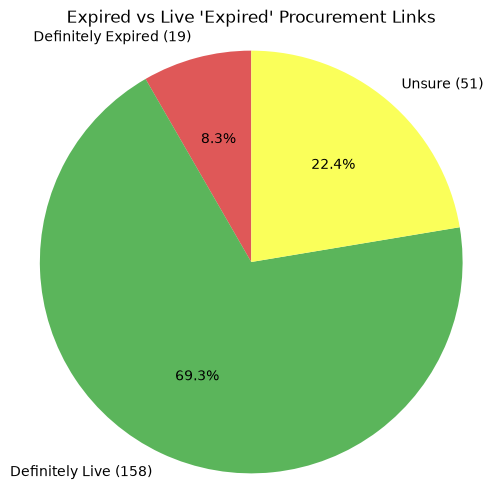

In [32]:
import pandas as pd

today = pd.Timestamp("2026-07-29")
df_expired = df[df['expired'] == True]

mask_404 = df_expired["latest_contract_deadline"] == "404"


contract_dates = pd.to_datetime(
    df_expired["latest_contract_deadline"],
    errors="coerce"
)

# Missing deadlines count as live
mask_expired = (
    ~mask_404
    & contract_dates.notna()
    & (contract_dates < today)
)

mask_live = (
    ~mask_404
    & ~mask_expired
)

num_404s = mask_404.sum()
num_expired = mask_expired.sum()
num_live = mask_live.sum()

print(f"404s: {num_404s}")
print(f"Expired: {num_expired}")
print(f"Live: {num_live}")


# Pie chart
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.pie(
    [num_expired, num_live, num_404s],
    labels=[f"Definitely Expired ({num_expired})", f"Definitely Live ({num_live})", f"Unsure ({num_404s})"],
    colors=["#d62727c5", "#2ca02cc6", "#faff5aff"],  # red, green
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Expired vs Live 'Expired' Procurement Links")

plt.axis("equal")
plt.show()

In [3]:
import plotly.graph_objects as go

num_expired = df['expired'].sum()      
num_live = (~df['expired']).sum()

fig = go.Figure(
    data=[
        go.Sankey(
            node=dict(
                label=["Current and Future Opportunities", "Live", "Expired"],
                pad=15,
                thickness=20
            ),
            link=dict(
                source=[0, 0],  # A -> B, A -> C
                target=[1, 2],
                value=[num_live, num_expired]
            )
        )
    ]
)

fig.show()

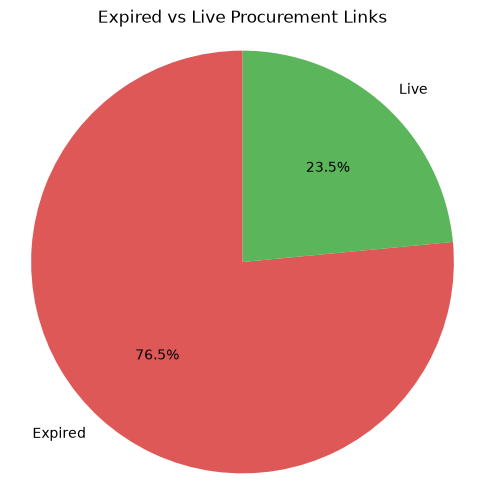

In [7]:
num_expired = df['expired'].sum()      
num_live = (~df['expired']).sum()

# Pie chart
import matplotlib.pyplot as plt

num_expired = df["expired"].sum()
num_live = (~df["expired"]).sum()

plt.figure(figsize=(6, 6))

plt.pie(
    [num_expired, num_live],
    labels=["Expired", "Live"],
    colors=["#d62727c5", "#2ca02cc6"],  # red, green
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Expired vs Live Procurement Links")

plt.axis("equal")
plt.show()

In [ ]:
import plotly.graph_objects as go

num_all = len(df)

num_broken = df["expired"].sum()
num_working = num_all - num_broken

def pct(n):
    return f"{(n / num_all) * 100:.1f}%"

fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="fixed",
            node=dict(
                pad=45,
                thickness=22,
                label=[
                    f"All Contracts ({pct(num_all)})",
                    f"Working Link ({pct(num_working)})",
                    f"Broken Link ({pct(num_broken)})",
                    f"Not Found in\nFind a Tender ({pct(num_404s)})",
                    f"Has Live\nSuccessor Contract ({pct(num_live)})",
                    f"Genuinely\nExpired ({pct(num_expired)})"
                ],
                color=[
                    "lightblue",
                    "#2ca02c",
                    "#d62728",
                    "#ff7f0e",
                    "#2ca02c",
                    "#8b0000"
                ],
                x=[
                    0.02,  # All Contracts
                    0.92,  # Working Link
                    0.42,  # Broken Link
                    0.92,  # Not Found
                    0.92,  # Has Live Successor
                    0.92   # Genuinely Expired
                ],
                y=[
                    0.42,  # All Contracts
                    0.05,  # Working Link
                    0.55,  # Broken Link
                    0.35,  # Not Found
                    0.62,  # Has Live Successor
                    0.93   # Genuinely Expired
                ]
            ),
            link=dict(
                source=[
                    0,  # All -> Working
                    0,  # All -> Broken
                    2,  # Broken -> Not Found
                    2,  # Broken -> Has Live Successor
                    2   # Broken -> Genuinely Expired
                ],
                target=[
                    1,
                    2,
                    3,
                    4,
                    5
                ],
                value=[
                    num_working,
                    num_broken,
                    num_404s,
                    num_live,
                    num_expired
                ],
                color=[
                    "rgba(44, 160, 44, 0.30)",
                    "rgba(214, 39, 40, 0.30)",
                    "rgba(255, 127, 14, 0.35)",
                    "rgba(44, 160, 44, 0.35)",
                    "rgba(139, 0, 0, 0.45)"
                ]
            )
        )
    ]
)

fig.update_layout(
    title="Outcomes of Broken Sell2Wales Contract Links",
    font_size=13,
    width=1150,
    height=750
)

fig.show()